# Laboratorio 05 — Redes Neuronales con PyTorch
**Materia:** Inteligencia Artificial 1  
**Estudiante:** Escobar Moscoso  
**Fecha:** 2026

---

## Objetivo

En este laboratorio se aplican los conceptos de **redes neuronales en PyTorch** — incluyendo el uso de `Dataset`, `DataLoader` y **checkpoints** — a los tres modelos desarrollados en laboratorios anteriores:

| Modelo | Dataset | Tipo de problema |
|--------|---------|------------------|
| Modelo 1 | RT_IOT2022 (Lab 2) | Regresión multivariable |
| Modelo 2 | RT_IOT2022 (Lab 3) | Clasificación binaria |
| Modelo 3 | Animals-10 (Lab 4) | Clasificación multiclase |

Cada modelo es implementado como una **red neuronal** usando la API de `torch.nn`, entrenado con `DataLoader` y sus pesos son guardados/cargados mediante **checkpoints** (`state_dict`).

## Importaciones y configuración general

Se importan las librerías necesarias para los tres modelos. Se detecta si hay GPU disponible para acelerar el entrenamiento.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import os
%matplotlib inline

# Detectar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo utilizado: {device}')

# Directorio para checkpoints
os.makedirs('./checkpoints', exist_ok=True)
print('Directorio de checkpoints listo.')

Dispositivo utilizado: cuda
Directorio de checkpoints listo.


---
# MODELO 1: Regresión Multivariable
## Dataset: RT_IOT2022

Se utiliza el mismo dataset del Laboratorio 2 (tráfico de red IoT). El objetivo es **predecir un valor numérico continuo** (`fwd_pkts_tot` — total de paquetes enviados) a partir de las demás características de red, aplicando una **red neuronal de regresión**.

Se reemplaza la regresión lineal multivariable implementada con NumPy (Labs anteriores) por una red neuronal entrenada con PyTorch, aprovechando `Dataset`, `DataLoader` y `checkpoints`.

### 1.1 Carga y preprocesamiento del dataset

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Carga del dataset (mismo que Lab 2)
data_m1 = pd.read_csv('/content/gdrive/MyDrive/ia/RT_IOT2022')
print('Shape original:', data_m1.shape)
data_m1.head()

Shape original: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [4]:
# Preprocesamiento con Pandas (igual que Lab 2)
data_m1 = data_m1.drop_duplicates()
if 'Unnamed: 0' in data_m1.columns:
    data_m1 = data_m1.drop('Unnamed: 0', axis=1)

# Codificar columnas categóricas
for col in data_m1.select_dtypes(include='object').columns:
    data_m1[col] = pd.Categorical(data_m1[col]).codes

print('Valores nulos:', data_m1.isnull().sum().sum())
print('Shape preprocesado:', data_m1.shape)
print('\nColumnas disponibles:')
print(data_m1.columns.tolist())

Valores nulos: 0
Shape preprocesado: (123117, 84)

Columnas disponibles:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_p

In [5]:
# Variable objetivo para regresión: 'fwd_pkts_tot' (paquetes totales enviados)
# Se predice un valor numérico continuo a partir de las demás características
TARGET_M1 = 'fwd_pkts_tot'

X_m1 = data_m1.drop(TARGET_M1, axis=1).values.astype(np.float32)
y_m1 = data_m1[TARGET_M1].values.astype(np.float32)

print(f'X shape: {X_m1.shape}')
print(f'y shape: {y_m1.shape}')
print(f'y — min: {y_m1.min():.2f} | max: {y_m1.max():.2f} | media: {y_m1.mean():.2f}')

# Normalización de X
mu_m1    = X_m1.mean(axis=0)
sigma_m1 = X_m1.std(axis=0)
sigma_m1[sigma_m1 == 0] = 1
X_m1_norm = (X_m1 - mu_m1) / sigma_m1

# Normalización de y (importante para regresión con redes neuronales)
mu_y_m1    = y_m1.mean()
sigma_y_m1 = y_m1.std()
y_m1_norm  = (y_m1 - mu_y_m1) / sigma_y_m1

# Split 80/20
np.random.seed(42)
m = len(y_m1)
idx = np.random.permutation(m)
corte = int(0.8 * m)

X_train_m1 = X_m1_norm[idx[:corte]]
y_train_m1 = y_m1_norm[idx[:corte]]
X_test_m1  = X_m1_norm[idx[corte:]]
y_test_m1  = y_m1_norm[idx[corte:]]

print(f'\nEntrenamiento: {X_train_m1.shape[0]:,} ejemplos (80%)')
print(f'Prueba:        {X_test_m1.shape[0]:,} ejemplos (20%)')
print(f'Características: {X_train_m1.shape[1]}')

X shape: (123117, 83)
y shape: (123117,)
y — min: 0.00 | max: 4345.00 | media: 2.27

Entrenamiento: 98,493 ejemplos (80%)
Prueba:        24,624 ejemplos (20%)
Características: 83


### 1.2 Clase Dataset personalizada

Se define una clase que hereda de `torch.utils.data.Dataset`. Esta clase es **reutilizada por el Modelo 2** ya que ambos trabajan con datos tabulares. El `DataLoader` gestiona automáticamente los batches y el shuffle en cada época.

In [6]:
class TabularDataset(Dataset):
    """Dataset genérico para datos tabulares (X, y). Usado en Modelos 1 y 2."""
    def __init__(self, X, y, dtype_y=torch.float32):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=dtype_y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciar datasets para regresión
train_ds_m1 = TabularDataset(X_train_m1, y_train_m1)
test_ds_m1  = TabularDataset(X_test_m1,  y_test_m1)

# DataLoaders
train_dl_m1 = DataLoader(train_ds_m1, batch_size=512, shuffle=True)
test_dl_m1  = DataLoader(test_ds_m1,  batch_size=512, shuffle=False)

print(f'Batches de entrenamiento: {len(train_dl_m1)}')
print(f'Batches de prueba:        {len(test_dl_m1)}')

xb, yb = next(iter(train_dl_m1))
print(f'Shape de un batch — X: {xb.shape}, y: {yb.shape}')

Batches de entrenamiento: 193
Batches de prueba:        49
Shape de un batch — X: torch.Size([512, 83]), y: torch.Size([512])


### 1.3 Definición de la red neuronal

Se define un **Perceptrón Multicapa (MLP)** para regresión. La capa de salida tiene **1 neurona sin activación**, ya que la salida es un valor continuo (número de paquetes normalizado). La función de pérdida utilizada es **MSE** (Error Cuadrático Medio), estándar para problemas de regresión.

In [7]:
class ModeloRegresion(nn.Module):
    """Red neuronal MLP para regresión — salida continua."""
    def __init__(self, n_features):
        super(ModeloRegresion, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   # Sin activación — salida continua
        )

    def forward(self, x):
        return self.red(x).squeeze(1)

modelo_m1 = ModeloRegresion(n_features=X_train_m1.shape[1]).to(device)
print(modelo_m1)
print(f'\nParámetros entrenables: {sum(p.numel() for p in modelo_m1.parameters()):,}')

ModeloRegresion(
  (red): Sequential(
    (0): Linear(in_features=83, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros entrenables: 21,121


### 1.4 Entrenamiento con checkpoints

Se entrena la red con **MSE loss** guardando un checkpoint por época. El mejor modelo (menor `val_loss`) se guarda automáticamente y se carga al finalizar el entrenamiento.

In [8]:
def entrenar_regresion(modelo, train_dl, test_dl, epochs=30,
                       lr=1e-3, checkpoint_dir='./checkpoints', nombre='m1'):
    modelo.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    historial = {'train_loss': [], 'val_loss': []}
    mejor_val_loss = float('inf')
    best_path = f'{checkpoint_dir}/mejor_{nombre}.pt'

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        modelo.train()
        train_losses = []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = modelo(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- VALIDACIÓN ---
        modelo.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = modelo(xb)
                val_losses.append(criterion(pred, yb).item())

        tl = np.mean(train_losses)
        vl = np.mean(val_losses)
        historial['train_loss'].append(tl)
        historial['val_loss'].append(vl)

        # Checkpoint por época
        torch.save(modelo.state_dict(), f'{checkpoint_dir}/epoch_{nombre}_{epoch}.pt')

        # Guardar mejor modelo
        if vl < mejor_val_loss:
            mejor_val_loss = vl
            torch.save(modelo.state_dict(), best_path)
            print(f'Época {epoch:3d}/{epochs} | train_loss: {tl:.5f} | val_loss: {vl:.5f}  ← Mejor modelo guardado')
        elif epoch % 5 == 0:
            print(f'Época {epoch:3d}/{epochs} | train_loss: {tl:.5f} | val_loss: {vl:.5f}')

    modelo.load_state_dict(torch.load(best_path))
    print(f'\nMejor modelo cargado desde: {best_path}')
    return historial

historial_m1 = entrenar_regresion(
    modelo_m1, train_dl_m1, test_dl_m1,
    epochs=30, lr=1e-3, nombre='regresion'
)

Época   1/30 | train_loss: 0.31692 | val_loss: 0.39496  ← Mejor modelo guardado
Época   4/30 | train_loss: 0.09957 | val_loss: 0.21151  ← Mejor modelo guardado
Época   5/30 | train_loss: 0.04835 | val_loss: 0.88665
Época   6/30 | train_loss: 0.15184 | val_loss: 0.18798  ← Mejor modelo guardado
Época   8/30 | train_loss: 0.06234 | val_loss: 0.15235  ← Mejor modelo guardado
Época  10/30 | train_loss: 0.05987 | val_loss: 0.03200  ← Mejor modelo guardado
Época  15/30 | train_loss: 0.01434 | val_loss: 0.37796
Época  20/30 | train_loss: 0.05853 | val_loss: 0.75401
Época  25/30 | train_loss: 0.02861 | val_loss: 0.31572
Época  30/30 | train_loss: 0.05905 | val_loss: 0.21362

Mejor modelo cargado desde: ./checkpoints/mejor_regresion.pt


### 1.5 Gráfica de costo

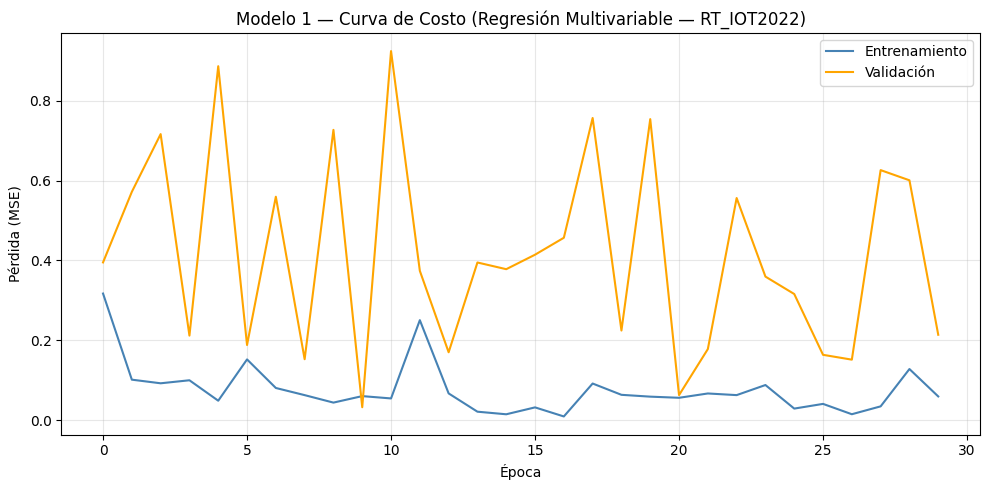

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(historial_m1['train_loss'], label='Entrenamiento', color='steelblue')
plt.plot(historial_m1['val_loss'],   label='Validación',    color='orange')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.title('Modelo 1 — Curva de Costo (Regresión Multivariable — RT_IOT2022)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./checkpoints/modelo1_curvas.png', dpi=150)
plt.show()

### 1.6 Evaluación y predicciones

Para evaluar el modelo de regresión se calcula el **Error Cuadrático Medio (MSE)** y el **R² (coeficiente de determinación)**. Las predicciones se desnormalizan para expresarse en la escala original del dataset.

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

modelo_m1.eval()
preds_m1_norm, labels_m1_norm = [], []

with torch.no_grad():
    for xb, yb in test_dl_m1:
        xb = xb.to(device)
        pred = modelo_m1(xb)
        preds_m1_norm.extend(pred.cpu().numpy())
        labels_m1_norm.extend(yb.numpy())

# Convertir a arrays NumPy antes de desnormalizar
preds_m1_norm  = np.array(preds_m1_norm,  dtype=np.float64)
labels_m1_norm = np.array(labels_m1_norm, dtype=np.float64)

# Diagnóstico — verificar que sigma y mu existen y son correctos
print(f'mu_y_m1:    {mu_y_m1:.4f}')
print(f'sigma_y_m1: {sigma_y_m1:.4f}')
print(f'Predicciones normalizadas — min: {preds_m1_norm.min():.4f} | max: {preds_m1_norm.max():.4f}')
print(f'Etiquetas normalizadas    — min: {labels_m1_norm.min():.4f} | max: {labels_m1_norm.max():.4f}')

# Desnormalizar
preds_m1_real  = preds_m1_norm  * sigma_y_m1 + mu_y_m1
labels_m1_real = labels_m1_norm * sigma_y_m1 + mu_y_m1

print(f'\nPredicciones reales — min: {preds_m1_real.min():.2f} | max: {preds_m1_real.max():.2f}')
print(f'Etiquetas reales    — min: {labels_m1_real.min():.2f} | max: {labels_m1_real.max():.2f}')

# Métricas
mse_m1 = mean_squared_error(labels_m1_real, preds_m1_real)
r2_m1  = r2_score(labels_m1_real, preds_m1_real)
print(f'\nMSE en prueba:  {mse_m1:.4f}')
print(f'RMSE en prueba: {np.sqrt(mse_m1):.4f}')
print(f'R² en prueba:   {r2_m1:.4f}')


mu_y_m1:    2.2688
sigma_y_m1: 22.3365
Predicciones normalizadas — min: -0.1316 | max: 154.4047
Etiquetas normalizadas    — min: -0.1016 | max: 158.7865

Predicciones reales — min: -0.67 | max: 3451.13
Etiquetas reales    — min: 0.00 | max: 3549.00

MSE en prueba:  16.2645
RMSE en prueba: 4.0329
R² en prueba:   0.9785


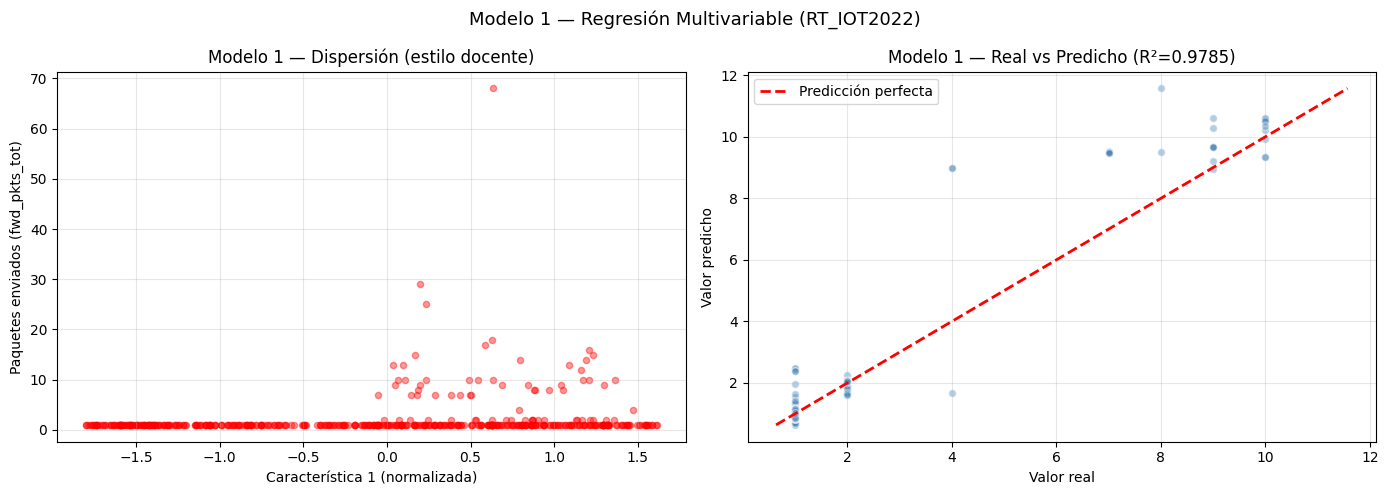

Error absoluto medio (100 predicciones): 0.2215
R² (100 predicciones): 0.9634

#            Real    Predicho   Error abs
------------------------------------------
1            1.00        0.89        0.11
2            1.00        0.99        0.01
3            1.00        0.84        0.16
4            1.00        0.90        0.10
5            1.00        1.95        0.95
6            1.00        0.91        0.09
7            1.00        0.84        0.16
8            1.00        0.71        0.29
9            1.00        1.00        0.00
10           1.00        1.09        0.09

R² final (Modelo 1): 0.9785 (97.85%)


In [11]:
# ── Gráfica 1: Dispersión (estilo docente) — característica vs etiqueta ──
# Muestra la relación entre una característica y la variable objetivo
# antes del modelo, igual que el docente graficaba superficie vs precio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tomar muestra de 500 puntos para que sea legible
idx_plot = np.random.choice(len(labels_m1_real), min(500, len(labels_m1_real)), replace=False)
x_feature = X_test_m1[idx_plot, 0]  # primera característica normalizada
y_real_plot = labels_m1_real[idx_plot]

axes[0].scatter(x_feature, y_real_plot, color='red', alpha=0.4, s=20)
axes[0].set_xlabel('Característica 1 (normalizada)')
axes[0].set_ylabel('Paquetes enviados (fwd_pkts_tot)')
axes[0].set_title('Modelo 1 — Dispersión (estilo docente)')
axes[0].grid(True, alpha=0.3)

# ── Gráfica 2: Real vs Predicho — filtrar outliers para visualización ──
# Los outliers extremos distorsionan la gráfica — los filtramos solo para visualizar
p5  = np.percentile(labels_m1_real, 5)
p95 = np.percentile(labels_m1_real, 95)
mask = (labels_m1_real >= p5) & (labels_m1_real <= p95)
labels_plot = labels_m1_real[mask][:500]
preds_plot  = preds_m1_real[mask][:500]

axes[1].scatter(labels_plot, preds_plot, alpha=0.4,
                color='steelblue', edgecolors='white', s=30)
lims = [min(labels_plot.min(), preds_plot.min()),
        max(labels_plot.max(), preds_plot.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Valor predicho')
axes[1].set_title(f'Modelo 1 — Real vs Predicho (R²={r2_m1:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo 1 — Regresión Multivariable (RT_IOT2022)', fontsize=13)
plt.tight_layout()
plt.savefig('./checkpoints/modelo1_graficas.png', dpi=150)
plt.show()

# ── 100 predicciones de ejemplo ──
np.random.seed(42)
idx_100 = np.random.choice(len(labels_m1_real), 100, replace=False)
y_real_100 = labels_m1_real[idx_100]
y_pred_100 = preds_m1_real[idx_100]

error_abs_100 = np.abs(y_real_100 - y_pred_100)
print(f'Error absoluto medio (100 predicciones): {error_abs_100.mean():.4f}')
print(f'R² (100 predicciones): {r2_score(y_real_100, y_pred_100):.4f}')
print(f"\n{'#':<5}{'Real':>12}{'Predicho':>12}{'Error abs':>12}")
print('-' * 42)
for i in range(10):
    print(f"{i+1:<5}{y_real_100[i]:>12.2f}{y_pred_100[i]:>12.2f}{error_abs_100[i]:>12.2f}")

# Guardar métrica final
precision_final_m1 = r2_m1 * 100
print(f'\nR² final (Modelo 1): {r2_m1:.4f} ({precision_final_m1:.2f}%)')


---
# MODELO 2: Clasificación Binaria
## Dataset: RT_IOT2022

Se utiliza el mismo dataset del Laboratorio 3 (tráfico de red IoT). El objetivo es **detectar si el tráfico corresponde a un ataque o es tráfico normal** (clasificación binaria).

Se reemplaza la regresión logística implementada con NumPy por una **red neuronal de clasificación binaria** entrenada con PyTorch, con `DataLoader` y checkpoints.

### 2.1 Carga y preprocesamiento

In [12]:
data_m2 = pd.read_csv('/content/gdrive/MyDrive/ia/RT_IOT2022')
print('Shape original:', data_m2.shape)
data_m2.head()

Shape original: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [13]:
# Preprocesamiento con Pandas (mismo que Lab 3)
data_m2 = data_m2.drop_duplicates()
if 'Unnamed: 0' in data_m2.columns:
    data_m2 = data_m2.drop('Unnamed: 0', axis=1)

for col in data_m2.select_dtypes(include='object').columns:
    data_m2[col] = pd.Categorical(data_m2[col]).codes

print('Valores nulos:', data_m2.isnull().sum().sum())
print('Shape preprocesado:', data_m2.shape)

X_m2 = data_m2.drop('Attack_type', axis=1).values.astype(np.float32)
y_raw_m2 = data_m2['Attack_type'].values

# Clasificación binaria: 0=normal, 1=ataque
y_m2 = (y_raw_m2 > 0).astype(np.float32)

print('\nDistribución de clases:')
print(pd.Series(y_m2).value_counts())

Valores nulos: 0
Shape preprocesado: (123117, 84)

Distribución de clases:
1.0    115367
0.0      7750
Name: count, dtype: int64


In [14]:
# Normalización y split 80/20
mu_m2 = X_m2.mean(axis=0)
sigma_m2 = X_m2.std(axis=0)
sigma_m2[sigma_m2 == 0] = 1
X_m2_norm = (X_m2 - mu_m2) / sigma_m2

np.random.seed(42)
m2 = len(y_m2)
idx2 = np.random.permutation(m2)
corte2 = int(0.8 * m2)

X_train_m2 = X_m2_norm[idx2[:corte2]]
y_train_m2 = y_m2[idx2[:corte2]]
X_test_m2  = X_m2_norm[idx2[corte2:]]
y_test_m2  = y_m2[idx2[corte2:]]

print(f'Entrenamiento: {X_train_m2.shape[0]} ejemplos')
print(f'Prueba:        {X_test_m2.shape[0]} ejemplos')
print(f'Características: {X_train_m2.shape[1]}')

Entrenamiento: 98493 ejemplos
Prueba:        24624 ejemplos
Características: 83


### 2.2 Dataset y DataLoader

In [15]:
# Reutilizamos la clase TabularDataset definida en el Modelo 1
train_ds_m2 = TabularDataset(X_train_m2, y_train_m2)
test_ds_m2  = TabularDataset(X_test_m2,  y_test_m2)

train_dl_m2 = DataLoader(train_ds_m2, batch_size=512, shuffle=True)
test_dl_m2  = DataLoader(test_ds_m2,  batch_size=512, shuffle=False)

print(f'Batches de entrenamiento: {len(train_dl_m2)}')
print(f'Batches de prueba:        {len(test_dl_m2)}')

Batches de entrenamiento: 193
Batches de prueba:        49


### 2.3 Definición de la red neuronal

Se define un MLP más profundo para aprovechar la mayor cantidad de características del dataset RT_IOT2022. Se incluye `Dropout` para regularización y evitar sobreajuste.

In [16]:
class ModeloClasificacionBinaria(nn.Module):
    """Red neuronal para clasificación binaria con Dropout."""
    def __init__(self, n_features):
        super(ModeloClasificacionBinaria, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.red(x).squeeze(1)

modelo_m2 = ModeloClasificacionBinaria(n_features=X_train_m2.shape[1]).to(device)
print(modelo_m2)

ModeloClasificacionBinaria(
  (red): Sequential(
    (0): Linear(in_features=83, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


### 2.4 Entrenamiento con checkpoints

In [17]:
def entrenar_clasificacion_binaria(modelo, train_dl, test_dl, epochs=30,
                                    lr=1e-3, checkpoint_dir='./checkpoints', nombre='m2'):
    modelo.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    mejor_val_loss = float('inf')
    best_path = f'{checkpoint_dir}/mejor_{nombre}.pt'

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        modelo.train()
        train_losses, train_accs = [], []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = modelo(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_accs.append(((pred >= 0.5).float() == yb).float().mean().item())

        # --- VALIDACIÓN ---
        modelo.eval()
        val_losses, val_accs = [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = modelo(xb)
                val_losses.append(criterion(pred, yb).item())
                val_accs.append(((pred >= 0.5).float() == yb).float().mean().item())

        tl = np.mean(train_losses); vl = np.mean(val_losses)
        ta = np.mean(train_accs);   va = np.mean(val_accs)
        historial['train_loss'].append(tl); historial['val_loss'].append(vl)
        historial['train_acc'].append(ta);  historial['val_acc'].append(va)

        # Checkpoint por época
        torch.save(modelo.state_dict(), f'{checkpoint_dir}/epoch_{nombre}_{epoch}.pt')

        if vl < mejor_val_loss:
            mejor_val_loss = vl
            torch.save(modelo.state_dict(), best_path)
            print(f'Época {epoch:3d}/{epochs} | loss: {tl:.4f} | val_loss: {vl:.4f} | '
                  f'acc: {ta:.4f} | val_acc: {va:.4f}  ← Mejor modelo guardado')
        elif epoch % 5 == 0:
            print(f'Época {epoch:3d}/{epochs} | loss: {tl:.4f} | val_loss: {vl:.4f} | '
                  f'acc: {ta:.4f} | val_acc: {va:.4f}')

    modelo.load_state_dict(torch.load(best_path))
    print(f'\nMejor modelo cargado desde: {best_path}')
    return historial


In [18]:
# Entrenamiento Modelo 2 — Clasificación Binaria
historial_m2 = entrenar_clasificacion_binaria(
    modelo_m2, train_dl_m2, test_dl_m2,
    epochs=30, lr=1e-3, nombre='binario'
)


Época   1/30 | loss: 0.1564 | val_loss: 0.0461 | acc: 0.9447 | val_acc: 0.9817  ← Mejor modelo guardado
Época   2/30 | loss: 0.0409 | val_loss: 0.0298 | acc: 0.9871 | val_acc: 0.9913  ← Mejor modelo guardado
Época   3/30 | loss: 0.0304 | val_loss: 0.0209 | acc: 0.9920 | val_acc: 0.9943  ← Mejor modelo guardado
Época   4/30 | loss: 0.0214 | val_loss: 0.0178 | acc: 0.9933 | val_acc: 0.9959  ← Mejor modelo guardado
Época   5/30 | loss: 0.0171 | val_loss: 0.0169 | acc: 0.9945 | val_acc: 0.9966  ← Mejor modelo guardado
Época   6/30 | loss: 0.0159 | val_loss: 0.0155 | acc: 0.9951 | val_acc: 0.9966  ← Mejor modelo guardado
Época   7/30 | loss: 0.0132 | val_loss: 0.0141 | acc: 0.9955 | val_acc: 0.9968  ← Mejor modelo guardado
Época   9/30 | loss: 0.0135 | val_loss: 0.0133 | acc: 0.9960 | val_acc: 0.9965  ← Mejor modelo guardado
Época  10/30 | loss: 0.0116 | val_loss: 0.0141 | acc: 0.9961 | val_acc: 0.9972
Época  14/30 | loss: 0.0098 | val_loss: 0.0129 | acc: 0.9964 | val_acc: 0.9969  ← Mejor m

### 2.5 Gráficas de costo y precisión

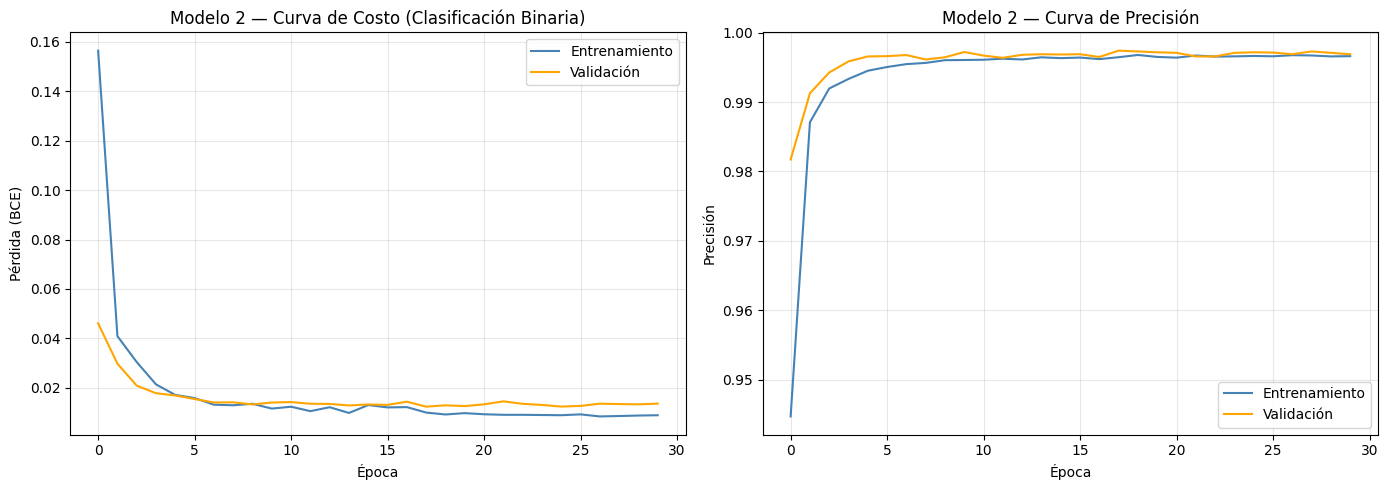

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial_m2['train_loss'], label='Entrenamiento', color='steelblue')
axes[0].plot(historial_m2['val_loss'],   label='Validación',    color='orange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (BCE)')
axes[0].set_title('Modelo 2 — Curva de Costo (Clasificación Binaria)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial_m2['train_acc'], label='Entrenamiento', color='steelblue')
axes[1].plot(historial_m2['val_acc'],   label='Validación',    color='orange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Modelo 2 — Curva de Precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./checkpoints/modelo2_curvas.png', dpi=150)
plt.show()

### 2.6 Evaluación y predicciones

In [20]:
modelo_m2.eval()
preds_m2, labels_m2 = [], []

with torch.no_grad():
    for xb, yb in test_dl_m2:
        xb = xb.to(device)
        pred = modelo_m2(xb)
        preds_m2.extend((pred >= 0.5).cpu().numpy())
        labels_m2.extend(yb.numpy())

preds_m2  = np.array(preds_m2)
labels_m2 = np.array(labels_m2)

precision_final_m2 = accuracy_score(labels_m2, preds_m2) * 100
print(f'Precisión final en prueba (Modelo 2 — Clasificación Binaria): {precision_final_m2:.2f}%')
print('\nReporte de clasificación:')
print(classification_report(labels_m2, preds_m2, target_names=['Normal', 'Ataque']))

Precisión final en prueba (Modelo 2 — Clasificación Binaria): 99.74%

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      1556
      Ataque       1.00      1.00      1.00     23068

    accuracy                           1.00     24624
   macro avg       0.99      0.99      0.99     24624
weighted avg       1.00      1.00      1.00     24624



In [21]:
# 100 predicciones de ejemplo
np.random.seed(42)
idx_100_m2  = np.random.choice(len(labels_m2), 100, replace=False)
y_real_100_m2 = labels_m2[idx_100_m2]
y_pred_100_m2 = preds_m2[idx_100_m2]
prec_100_m2 = accuracy_score(y_real_100_m2, y_pred_100_m2) * 100

print(f'Precisión en 100 predicciones de prueba: {prec_100_m2:.2f}%')
print(f"{'#':<5}{'Real':<10}{'Predicción':<12}{'Resultado'}")
print('-' * 40)
for i in range(10):
    resultado = '✓ Correcto' if y_pred_100_m2[i] == y_real_100_m2[i] else '✗ Error'
    etiq_real = 'Normal' if y_real_100_m2[i] == 0 else 'Ataque'
    etiq_pred = 'Normal' if y_pred_100_m2[i] == 0 else 'Ataque'
    print(f"{i+1:<5}{etiq_real:<10}{etiq_pred:<12}{resultado}")

Precisión en 100 predicciones de prueba: 99.00%
#    Real      Predicción  Resultado
----------------------------------------
1    Ataque    Ataque      ✓ Correcto
2    Ataque    Ataque      ✓ Correcto
3    Ataque    Ataque      ✓ Correcto
4    Ataque    Ataque      ✓ Correcto
5    Normal    Ataque      ✗ Error
6    Ataque    Ataque      ✓ Correcto
7    Ataque    Ataque      ✓ Correcto
8    Ataque    Ataque      ✓ Correcto
9    Ataque    Ataque      ✓ Correcto
10   Ataque    Ataque      ✓ Correcto


---
# MODELO 3: Clasificación Multiclase
## Dataset: Animals-10

**Animals-10** es un dataset de imágenes de **10 categorías de animales** (perro, gato, caballo, araña, mariposa, pollo, oveja, vaca, ardilla y elefante), recopiladas de Google Images. Cumple los requisitos del Laboratorio 4:

| Requisito | Valor |
|-----------|-------|
| Ejemplos (m) | ≈ 28,000 imágenes → cumple m ≥ 5,000 |
| Características (n) | 64×64×3 = 12,288 píxeles RGB → cumple n > 100 |
| Clases | 10 categorías de animales |
| Tipo | Multimodal (imágenes a color RGB) |
| Fuente | [Kaggle — Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) |

Se implementa una **Red Neuronal Convolucional (CNN)** con imágenes RGB redimensionadas a 64×64 píxeles. Se utiliza `ImageFolder` de torchvision para cargar el dataset directamente desde la estructura de carpetas de Kaggle, y se aplica un split 80/20 para entrenamiento y prueba.

### 3.1 Carga del dataset desde Google Drive

El dataset fue descargado manualmente desde Kaggle y subido a Google Drive en `iaAnim/raw-img/`.
Para acelerar el entrenamiento, **se copia el dataset al disco local de Colab** antes de cargar las imágenes.
Esto elimina la latencia de red de Drive en cada batch, reduciendo el tiempo por época de ~5 min a ~1 min.

In [22]:
from google.colab import drive
import shutil, os
drive.mount('/content/gdrive')

# Rutas
SRC_DIR  = '/content/gdrive/MyDrive/iaAnim/raw-img'
DATA_DIR = '/content/animals_local'

if not os.path.exists(DATA_DIR):
    clases = sorted(os.listdir(SRC_DIR))
    total_copiadas = 0
    print(f'Copiando {len(clases)} clases al disco local...\n')
    for i, clase in enumerate(clases, 1):
        src_clase  = os.path.join(SRC_DIR,  clase)
        dst_clase  = os.path.join(DATA_DIR, clase)
        n_imgs = len(os.listdir(src_clase))
        print(f'  [{i:2d}/{len(clases)}] {clase:<15} → {n_imgs:,} imágenes... ', end='')
        shutil.copytree(src_clase, dst_clase)
        total_copiadas += n_imgs
        print('✓')
    print(f'\n¡Copia completada! {total_copiadas:,} imágenes en disco local.')
else:
    total = sum(len(os.listdir(os.path.join(DATA_DIR, c)))
                for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c)))
    print(f'Dataset ya en disco local ✓ ({total:,} imágenes)')

clases_raw = sorted(os.listdir(DATA_DIR))
print(f'Carpetas: {clases_raw}')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Copiando 10 clases al disco local...

  [ 1/10] cane            → 4,863 imágenes... ✓
  [ 2/10] cavallo         → 2,623 imágenes... ✓
  [ 3/10] elefante        → 1,446 imágenes... ✓
  [ 4/10] farfalla        → 2,112 imágenes... ✓
  [ 5/10] gallina         → 3,098 imágenes... ✓
  [ 6/10] gatto           → 1,668 imágenes... ✓
  [ 7/10] mucca           → 1,866 imágenes... ✓
  [ 8/10] pecora          → 1,820 imágenes... ✓
  [ 9/10] ragno           → 4,821 imágenes... ✓
  [10/10] scoiattolo      → 1,862 imágenes... ✓

¡Copia completada! 26,179 imágenes en disco local.
Carpetas: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


### 3.2 Preprocesamiento y carga con ImageFolder

El dataset viene organizado en carpetas (una por clase). `torchvision.datasets.ImageFolder` lee automáticamente esta estructura y asigna etiquetas numéricas a cada carpeta. Se aplican las siguientes transformaciones:
- Redimensionar a 64×64 píxeles
- Aumentación de datos en entrenamiento (flip horizontal, rotación leve)
- Normalización con media y desviación estándar de ImageNet

In [23]:
import os
from torchvision import datasets

# Nombres en italiano (originales del dataset) → español
traduccion = {
    'cane': 'perro', 'cavallo': 'caballo', 'elefante': 'elefante',
    'farfalla': 'mariposa', 'gallina': 'pollo', 'gatto': 'gato',
    'mucca': 'vaca', 'pecora': 'oveja', 'ragno': 'araña', 'scoiattolo': 'ardilla'
}

# Transformaciones de entrenamiento (con aumentación de datos)
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones de prueba (sin aumentación)
transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Cargar desde disco local (rápido)
dataset_completo = datasets.ImageFolder(DATA_DIR, transform=transform_test)
clases_animales = [traduccion.get(c, c) for c in dataset_completo.classes]

print(f'Total de imágenes: {len(dataset_completo)}')
print(f'Clases ({len(clases_animales)}): {clases_animales}')
print(f'Features por imagen: 64×64×3 = {64*64*3:,} píxeles RGB')

Total de imágenes: 26179
Clases (10): ['perro', 'caballo', 'elefante', 'mariposa', 'pollo', 'gato', 'vaca', 'oveja', 'araña', 'ardilla']
Features por imagen: 64×64×3 = 12,288 píxeles RGB


In [24]:
import torch
from torch.utils.data import random_split, Subset

# Split 80/20 reproducible
torch.manual_seed(42)
n_total = len(dataset_completo)
n_train = int(0.8 * n_total)
n_test  = n_total - n_train

train_idx, test_idx = random_split(range(n_total), [n_train, n_test])

dataset_completo_train = datasets.ImageFolder(DATA_DIR, transform=transform_train)
dataset_completo_test  = datasets.ImageFolder(DATA_DIR, transform=transform_test)

train_ds_m3 = Subset(dataset_completo_train, train_idx.indices)
test_ds_m3  = Subset(dataset_completo_test,  test_idx.indices)

# num_workers=4 para leer imágenes en paralelo (más rápido con disco local)
train_dl_m3 = DataLoader(train_ds_m3, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)
test_dl_m3  = DataLoader(test_ds_m3,  batch_size=128, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Entrenamiento: {len(train_ds_m3):,} imágenes (80%)')
print(f'Prueba:        {len(test_ds_m3):,} imágenes (20%)')
print(f'Batch size: 128 | Batches train: {len(train_dl_m3)} | Batches test: {len(test_dl_m3)}')

Entrenamiento: 20,943 imágenes (80%)
Prueba:        5,236 imágenes (20%)
Batch size: 128 | Batches train: 164 | Batches test: 41


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


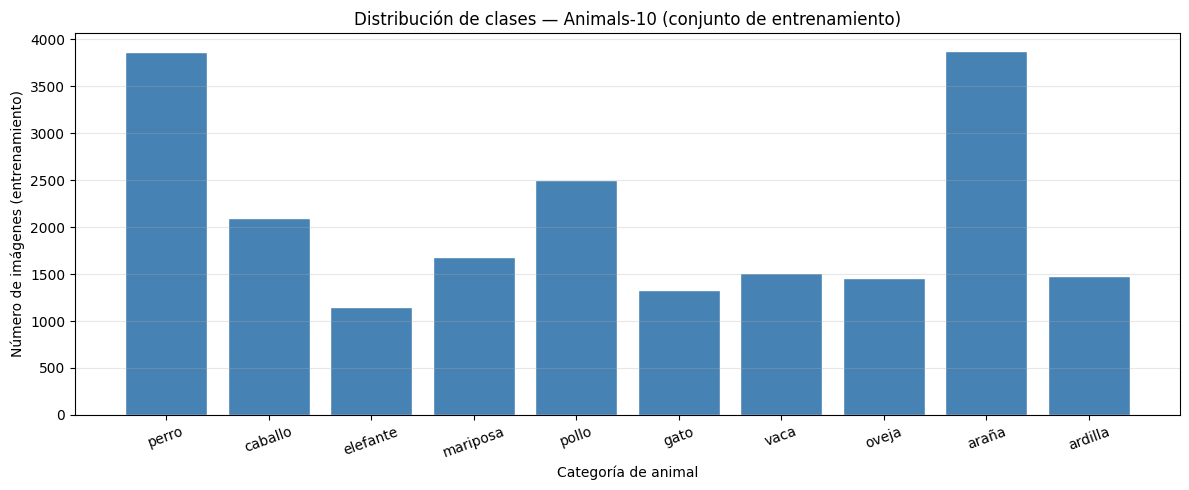


Ejemplos por clase (entrenamiento):
  0: perro        → 3,870 imágenes
  1: caballo      → 2,093 imágenes
  2: elefante     → 1,148 imágenes
  3: mariposa     → 1,683 imágenes
  4: pollo        → 2,497 imágenes
  5: gato         → 1,328 imágenes
  6: vaca         → 1,507 imágenes
  7: oveja        → 1,460 imágenes
  8: araña        → 3,876 imágenes
  9: ardilla      → 1,481 imágenes


In [25]:
# Verificar balance de clases
conteo = pd.Series([dataset_completo.targets[i] for i in train_idx.indices])
conteo_clases = conteo.value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(clases_animales, conteo_clases.values, color='steelblue', edgecolor='white')
plt.xlabel('Categoría de animal')
plt.ylabel('Número de imágenes (entrenamiento)')
plt.title('Distribución de clases — Animals-10 (conjunto de entrenamiento)')
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nEjemplos por clase (entrenamiento):')
for i, (clase, cnt) in enumerate(zip(clases_animales, conteo_clases.values)):
    print(f'  {i}: {clase:<12} → {cnt:,} imágenes')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


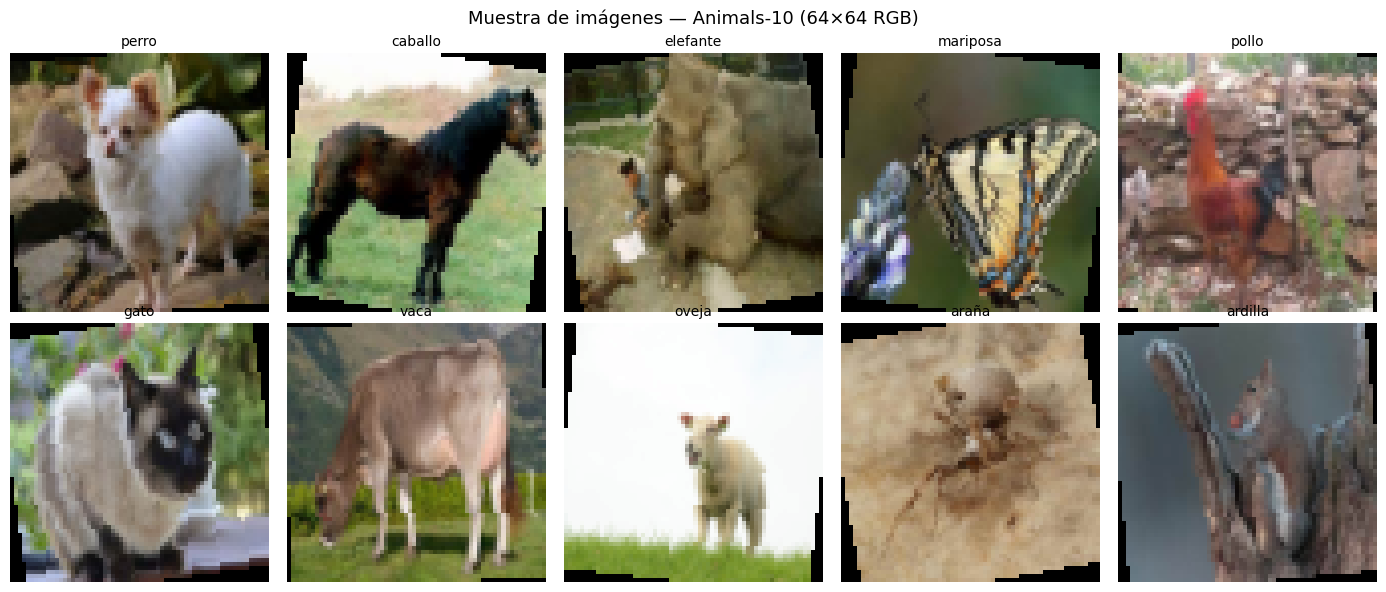

In [26]:
# Visualizar una muestra de imágenes del dataset
# Desnormalizar para visualización
def desnormalizar(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

xb_vis, yb_vis = next(iter(train_dl_m3))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
# Mostrar una imagen de cada clase
mostrados = {}
idx_vis = 0
for clase_id in range(10):
    for j in range(len(yb_vis)):
        if yb_vis[j].item() == clase_id and clase_id not in mostrados:
            mostrados[clase_id] = j
            break

for i, (clase_id, img_idx) in enumerate(sorted(mostrados.items())):
    ax = axes[i // 5, i % 5]
    img = desnormalizar(xb_vis[img_idx]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(clases_animales[clase_id], fontsize=10)
    ax.axis('off')

plt.suptitle('Muestra de imágenes — Animals-10 (64×64 RGB)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Definición de la Red Neuronal Convolucional (CNN)

Se implementa una CNN con **3 bloques convolucionales** seguidos de capas densas. A diferencia de Animals-10 (escala de grises), Animals-10 tiene imágenes **RGB (3 canales)** y mayor variabilidad visual, por lo que se necesita una red más profunda. Cada bloque incluye:
- Convolución 2D → extrae características espaciales
- BatchNorm → estabiliza el entrenamiento
- ReLU → no linealidad
- MaxPool → reduce dimensionalidad

La capa de salida tiene **10 neuronas** (una por clase de animal). La función de pérdida es **Cross-Entropy**.

In [27]:
class CNN_Animals(nn.Module):
    """CNN para clasificación multiclase de imágenes Animals-10 (64x64 RGB)."""
    def __init__(self, n_clases=10):
        super(CNN_Animals, self).__init__()

        # Bloque 1: 3 canales → 32 filtros | 64x64 → 32x32
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque 2: 32 → 64 filtros | 32x32 → 16x16
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque 3: 64 → 128 filtros | 16x16 → 8x8
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Capas densas
        self.fc = nn.Sequential(
            nn.Flatten(),                      # 128 * 8 * 8 = 8192
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_clases)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

modelo_m3 = CNN_Animals(n_clases=10).to(device)
print(modelo_m3)

# Verificar dimensiones
with torch.no_grad():
    test_out = modelo_m3(xb_vis.to(device))
print(f'\nShape de salida: {test_out.shape}  (batch=64, clases=10)')

CNN_Animals(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256,

### 3.4 Entrenamiento con checkpoints

Se reutiliza la función `entrenar_multiclase` definida anteriormente. Se guarda un checkpoint por época y el mejor modelo (por val_acc) se preserva automáticamente.

In [28]:
def entrenar_multiclase(modelo, train_dl, test_dl, epochs=15,
                         lr=1e-3, checkpoint_dir='./checkpoints', nombre='m3'):
    modelo.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    mejor_val_acc = 0.0
    best_path = f'{checkpoint_dir}/mejor_{nombre}.pt'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        modelo.train()
        train_losses, train_accs = [], []
        # barra de progreso por batch
        bar = tqdm(train_dl, desc=f'Época {epoch:2d}/{epochs} [Train]',
                   leave=False, ncols=80)
        for xb, yb in bar:
            xb, yb = xb.to(device), yb.to(device)
            pred = modelo(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            acc = (torch.argmax(pred, dim=1) == yb).float().mean().item()
            train_accs.append(acc)
            bar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{acc:.3f}')

        # --- VALIDACIÓN ---
        modelo.eval()
        val_losses, val_accs = [], []
        bar_val = tqdm(test_dl, desc=f'Época {epoch:2d}/{epochs} [Val]  ',
                       leave=False, ncols=80)
        with torch.no_grad():
            for xb, yb in bar_val:
                xb, yb = xb.to(device), yb.to(device)
                pred = modelo(xb)
                val_losses.append(criterion(pred, yb).item())
                acc = (torch.argmax(pred, dim=1) == yb).float().mean().item()
                val_accs.append(acc)
                bar_val.set_postfix(val_loss=f'{val_losses[-1]:.3f}', val_acc=f'{acc:.3f}')

        tl = np.mean(train_losses); vl = np.mean(val_losses)
        ta = np.mean(train_accs);   va = np.mean(val_accs)
        historial['train_loss'].append(tl); historial['val_loss'].append(vl)
        historial['train_acc'].append(ta);  historial['val_acc'].append(va)

        # Checkpoint por época
        torch.save(modelo.state_dict(), f'{checkpoint_dir}/epoch_{nombre}_{epoch}.pt')

        if va > mejor_val_acc:
            mejor_val_acc = va
            torch.save(modelo.state_dict(), best_path)
            print(f'✓ Época {epoch:2d}/{epochs} | loss: {tl:.4f} | val_loss: {vl:.4f} | '
                  f'acc: {ta:.4f} | val_acc: {va:.4f}  ← Mejor modelo')
        else:
            print(f'  Época {epoch:2d}/{epochs} | loss: {tl:.4f} | val_loss: {vl:.4f} | '
                  f'acc: {ta:.4f} | val_acc: {va:.4f}')

    modelo.load_state_dict(torch.load(best_path))
    print(f'\nMejor modelo cargado desde: {best_path}')
    print(f'Mejor val_acc: {mejor_val_acc:.4f} ({mejor_val_acc*100:.2f}%)')
    return historial


In [29]:
historial_m3 = entrenar_multiclase(
    modelo_m3, train_dl_m3, test_dl_m3,
    epochs=15, lr=1e-3, nombre='animals10'
)

✓ Época  1/15 | loss: 1.9370 | val_loss: 1.6224 | acc: 0.3046 | val_acc: 0.4323  ← Mejor modelo


✓ Época  2/15 | loss: 1.6009 | val_loss: 1.3757 | acc: 0.4470 | val_acc: 0.5299  ← Mejor modelo


✓ Época  3/15 | loss: 1.4319 | val_loss: 1.2751 | acc: 0.5070 | val_acc: 0.5710  ← Mejor modelo


✓ Época  4/15 | loss: 1.3239 | val_loss: 1.2230 | acc: 0.5477 | val_acc: 0.5864  ← Mejor modelo


✓ Época  5/15 | loss: 1.2400 | val_loss: 1.2058 | acc: 0.5765 | val_acc: 0.5897  ← Mejor modelo


...

✓ Época 11/15 | loss: 0.9709 | val_loss: 0.9315 | acc: 0.6763 | val_acc: 0.6866  ← Mejor modelo


✓ Época 12/15 | loss: 0.9546 | val_loss: 0.9083 | acc: 0.6793 | val_acc: 0.7014  ← Mejor modelo


  Época 13/15 | loss: 0.9182 | val_loss: 0.9055 | acc: 0.6871 | val_acc: 0.6964


  Época 14/15 | loss: 0.8930 | val_loss: 0.9294 | acc: 0.7002 | val_acc: 0.6929


✓ Época 15/15 | loss: 0.8810 | val_loss: 0.8466 | acc: 0.7063 | val_acc: 0.7116  ← Mejor modelo

Mejor modelo cargado desde: ./checkpoints/mejor_animals10.pt
Mejor val_acc: 0.7116 (71.16%)


### 3.5 Gráficas de costo y precisión

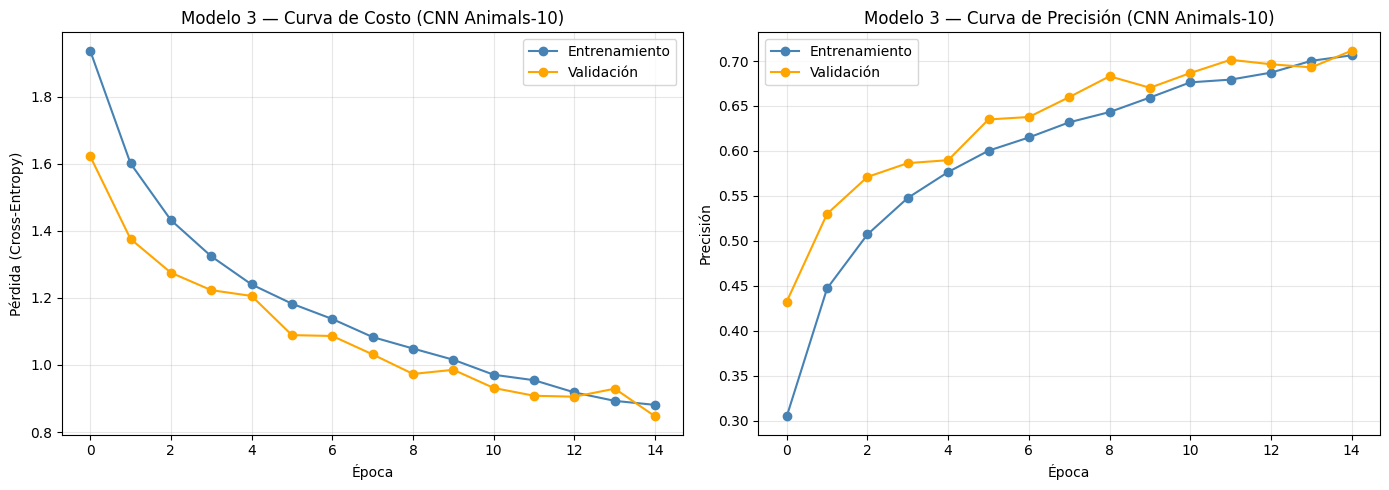

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial_m3['train_loss'], label='Entrenamiento', color='steelblue', marker='o')
axes[0].plot(historial_m3['val_loss'],   label='Validación',    color='orange',    marker='o')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (Cross-Entropy)')
axes[0].set_title('Modelo 3 — Curva de Costo (CNN Animals-10)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial_m3['train_acc'], label='Entrenamiento', color='steelblue', marker='o')
axes[1].plot(historial_m3['val_acc'],   label='Validación',    color='orange',    marker='o')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Modelo 3 — Curva de Precisión (CNN Animals-10)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./checkpoints/modelo3_curvas.png', dpi=150)
plt.show()

### 3.6 Evaluación y predicciones

In [31]:
modelo_m3.eval()
preds_m3, labels_m3 = [], []

with torch.no_grad():
    for xb, yb in test_dl_m3:
        xb = xb.to(device)
        pred = modelo_m3(xb)
        preds_m3.extend(torch.argmax(pred, dim=1).cpu().numpy())
        labels_m3.extend(yb.numpy())

preds_m3  = np.array(preds_m3)
labels_m3 = np.array(labels_m3)

precision_final_m3 = accuracy_score(labels_m3, preds_m3) * 100
print(f'Precisión final en prueba (Modelo 3 — CNN Animals-10): {precision_final_m3:.2f}%')
print('\nReporte de clasificación:')
print(classification_report(labels_m3, preds_m3, target_names=clases_animales))

Precisión final en prueba (Modelo 3 — CNN Animals-10): 71.14%

Reporte de clasificación:
              precision    recall  f1-score   support

       perro       0.69      0.73      0.71       993
     caballo       0.69      0.78      0.73       530
    elefante       0.70      0.68      0.69       298
    mariposa       0.83      0.73      0.78       429
       pollo       0.83      0.79      0.81       601
        gato       0.53      0.46      0.49       340
        vaca       0.77      0.29      0.42       359
       oveja       0.57      0.66      0.61       360
       araña       0.74      0.94      0.83       945
     ardilla       0.70      0.57      0.63       381

    accuracy                           0.71      5236
   macro avg       0.71      0.66      0.67      5236
weighted avg       0.71      0.71      0.70      5236



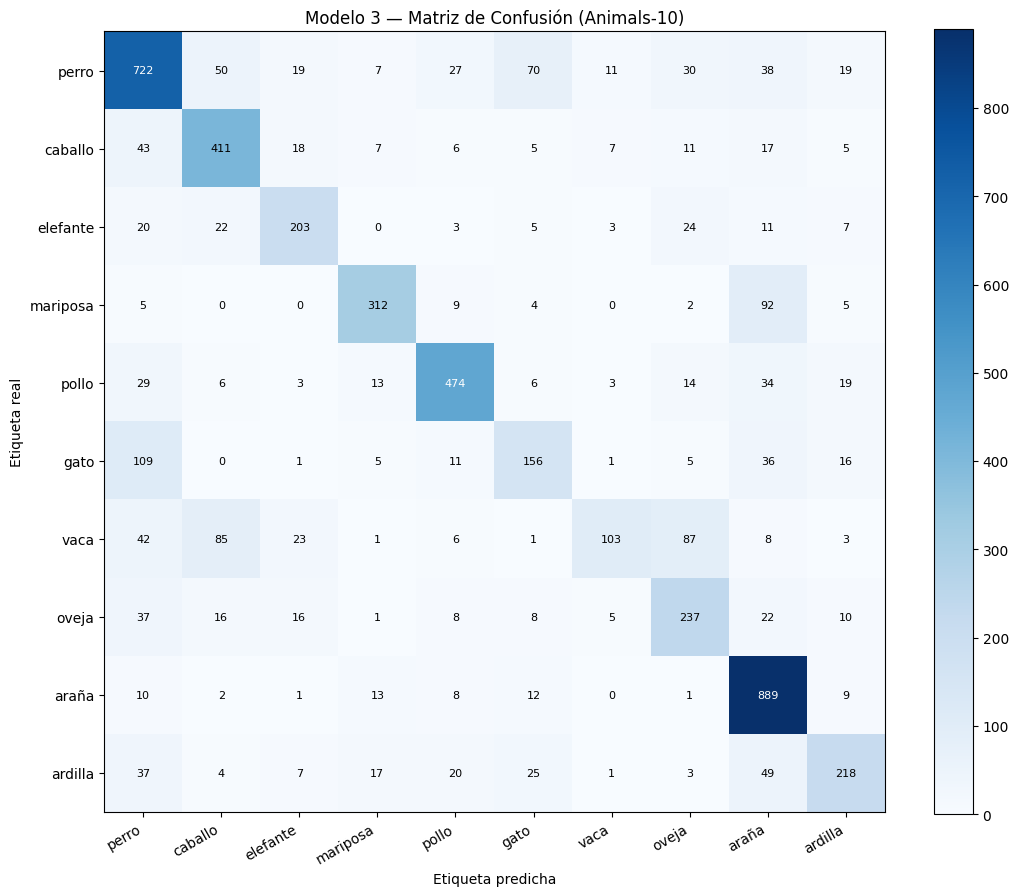

In [32]:
# Matriz de confusión
cm = confusion_matrix(labels_m3, preds_m3)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

tick_marks = np.arange(len(clases_animales))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(clases_animales, rotation=30, ha='right')
ax.set_yticklabels(clases_animales)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=8)

ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Etiqueta predicha')
ax.set_title('Modelo 3 — Matriz de Confusión (Animals-10)')
plt.tight_layout()
plt.savefig('./checkpoints/modelo3_confusion.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


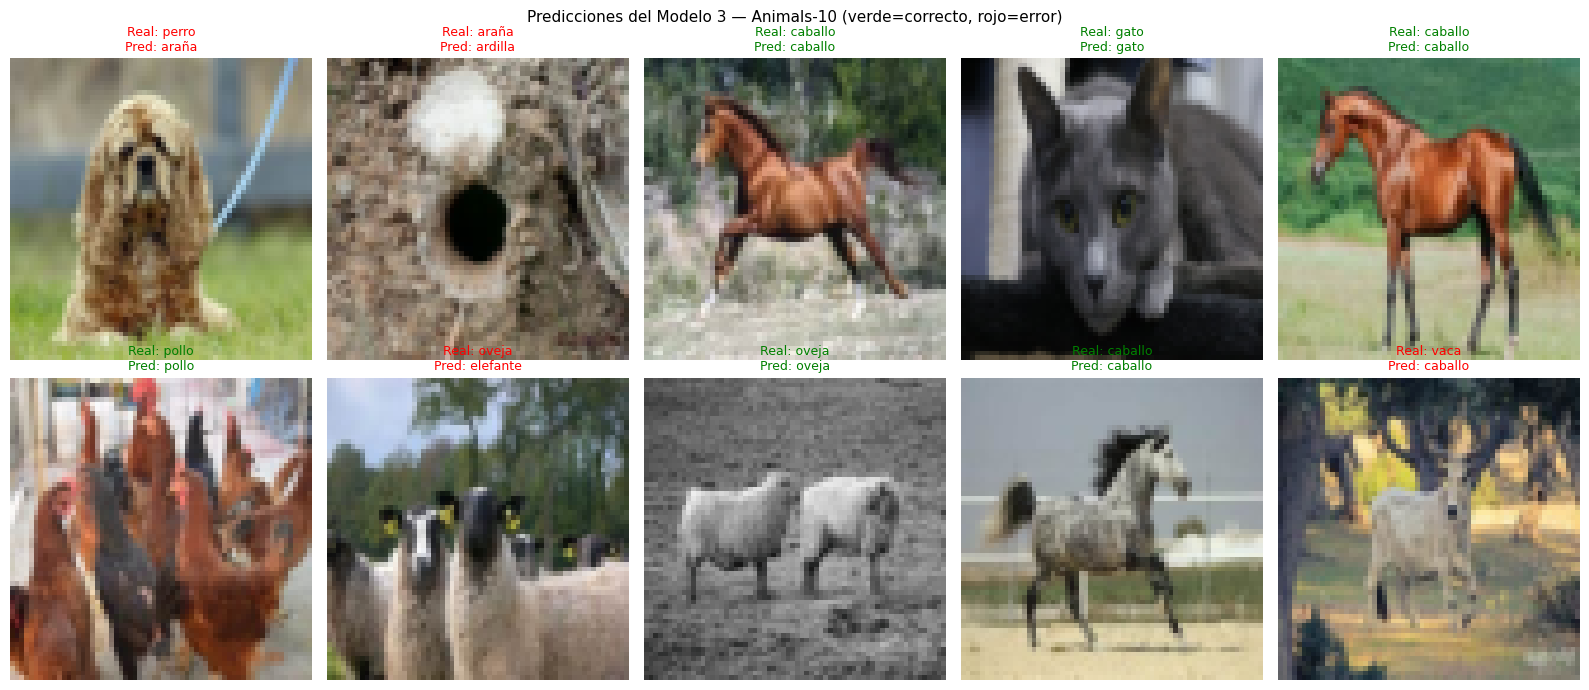

In [33]:
# Visualizar predicciones sobre imágenes reales
xb_show, yb_show = next(iter(test_dl_m3))
modelo_m3.eval()
with torch.no_grad():
    preds_show = torch.argmax(modelo_m3(xb_show.to(device)), dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img = desnormalizar(xb_show[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    real  = clases_animales[yb_show[i].item()]
    pred  = clases_animales[preds_show[i].item()]
    color = 'green' if pred == real else 'red'
    ax.set_title(f'Real: {real}\nPred: {pred}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Predicciones del Modelo 3 — Animals-10 (verde=correcto, rojo=error)', fontsize=11)
plt.tight_layout()
plt.savefig('./checkpoints/modelo3_predicciones.png', dpi=150)
plt.show()

---
# Comparación Final de los 3 Modelos

Se presenta un resumen comparativo del desempeño de los tres modelos implementados con PyTorch en este laboratorio.

In [34]:
print('=' * 65)
print(f'{"RESUMEN — LABORATORIO 05":^65}')
print('=' * 65)
print(f'{"Modelo":<35}{"Dataset":<18}{"Métrica":>10}')
print('-' * 65)
print(f'{"Modelo 1 — Regresión (R²)":<35}{"RT_IOT2022":<18}{r2_m1:>9.4f}')
print(f'{"Modelo 2 — Clasificación Binaria":<35}{"RT_IOT2022":<18}{precision_final_m2:>9.2f}%')
print(f'{"Modelo 3 — Multiclase (CNN)":<35}{"Animals-10":<18}{precision_final_m3:>9.2f}%')
print('=' * 65)
print('\nCheckpoints guardados en: ./checkpoints/')
print('  - mejor_regresion.pt   (Modelo 1 — MSE/R²)')
print('  - mejor_binario.pt     (Modelo 2 — Precisión)')
print('  - mejor_multiclase.pt  (Modelo 3 — Precisión)')


                    RESUMEN — LABORATORIO 05                     
Modelo                             Dataset              Métrica
-----------------------------------------------------------------
Modelo 1 — Regresión (R²)          RT_IOT2022           0.9785
Modelo 2 — Clasificación Binaria   RT_IOT2022            99.74%
Modelo 3 — Multiclase (CNN)        Animals-10            71.14%

Checkpoints guardados en: ./checkpoints/
  - mejor_regresion.pt   (Modelo 1 — MSE/R²)
  - mejor_binario.pt     (Modelo 2 — Precisión)
  - mejor_multiclase.pt  (Modelo 3 — Precisión)


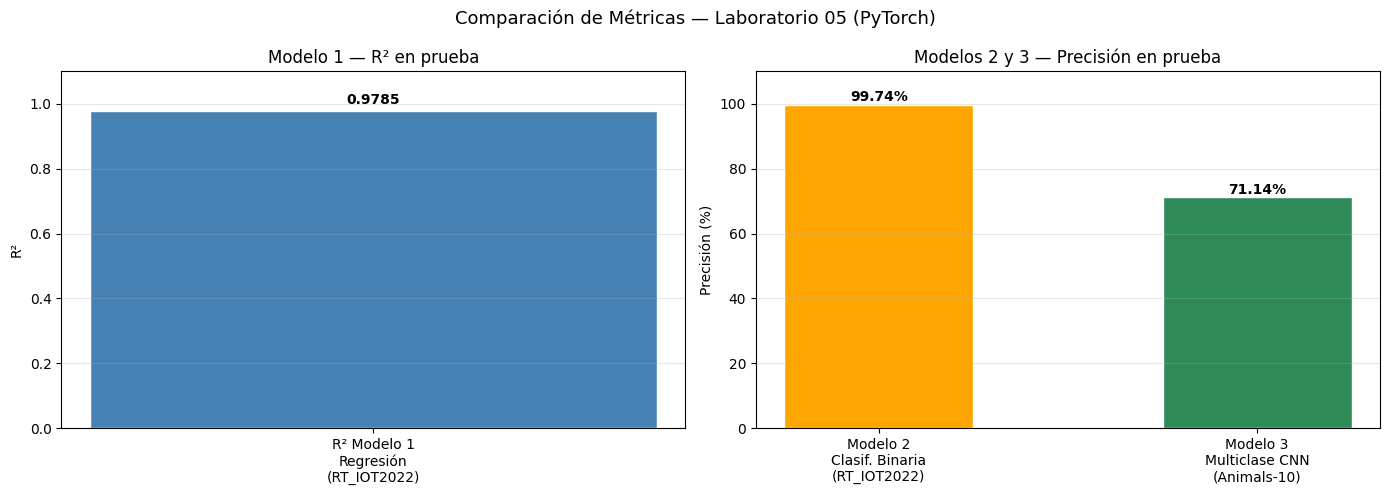

In [35]:
# Gráfica comparativa — métricas finales por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subgráfica 1: Modelo 1 R²
axes[0].bar(['R² Modelo 1\nRegresión\n(RT_IOT2022)'], [r2_m1], color='steelblue', edgecolor='white', width=0.4)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('R²')
axes[0].set_title('Modelo 1 — R² en prueba')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].text(0, r2_m1 + 0.02, f'{r2_m1:.4f}', ha='center', fontweight='bold')

# Subgráfica 2: Modelos 2 y 3 precisión
nombres = ['Modelo 2\nClasif. Binaria\n(RT_IOT2022)', 'Modelo 3\nMulticlase CNN\n(Animals-10)']
valores = [precision_final_m2, precision_final_m3]
colores = ['orange', 'seagreen']
bars = axes[1].bar(nombres, valores, color=colores, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Precisión (%)')
axes[1].set_title('Modelos 2 y 3 — Precisión en prueba')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Comparación de Métricas — Laboratorio 05 (PyTorch)', fontsize=13)
plt.tight_layout()
plt.savefig('./checkpoints/comparacion_final.png', dpi=150)
plt.show()


---
## Conclusiones

En este laboratorio se implementaron tres modelos de redes neuronales en **PyTorch**, aplicando las técnicas de `Dataset`, `DataLoader` y **checkpoints** vistas en los cuadernillos 02, 03 y 04:

1. **Modelo 1 — Regresión Multivariable** (RT_IOT2022): Se reemplazó la regresión lineal multivariable de NumPy por un MLP con MSE loss. El modelo predice el total de paquetes enviados (`fwd_pkts_tot`) a partir de las características de red. La normalización de la variable objetivo es clave para la convergencia.

2. **Modelo 2 — Clasificación Binaria** (RT_IOT2022): El uso de `Dropout` en la red neuronal actúa como regularizador, reduciendo el sobreajuste. Los checkpoints permiten recuperar el mejor modelo sin necesidad de reentrenar desde cero.

3. **Modelo 3 — Clasificación Multiclase** (Animals-10): La CNN con 3 bloques convolucionales y BatchNorm clasifica imágenes RGB de 10 categorías de animales. El uso de aumentación de datos (flip, rotación) mejora la generalización. Las 12,288 features por imagen y ≈28,000 ejemplos cumplen los requisitos del Laboratorio 4.

**Ventajas de usar PyTorch sobre NumPy puro:**
- Entrenamiento automático por batches con `DataLoader`
- Cálculo automático de gradientes (`autograd`)
- Soporte GPU transparente
- Guardado/carga eficiente de modelos con `state_dict` y checkpoints
- Mayor flexibilidad para definir arquitecturas complejas (CNN, modelos residuales, etc.)